# Neural Networks for Binary Classification: Heart Disease Diagnosis

## Overview
Build a neural network to predict heart disease from clinical measurements. Expected accuracy: **80-85%** on test data.

## Learning Objectives
✓ Load and explore real medical dataset from online source
✓ Preprocess data (scaling, train-test split)  
✓ Design and train a neural network  
✓ Evaluate performance and compare architectures

In [19]:
# Set random seeds for reproducible results
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

# Data processing and visualization
import numpy as np                           # Numerical computing
import pandas as pd                          # Data manipulation
from sklearn.datasets import load_breast_cancer  # Load biomedical dataset
from sklearn.model_selection import train_test_split  # Split data into train/test
from sklearn.preprocessing import StandardScaler    # Scale features (normalize values)
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score  # Evaluation metrics

# Deep learning
from tensorflow.keras import models, layers  # Build neural network
from tensorflow.keras.optimizers import Adam  # Optimizer for training
from tensorflow.keras.callbacks import EarlyStopping  # Stop training when validation loss plateaus

# Visualization
import matplotlib.pyplot as plt              # Plot training curves and results
import seaborn as sns                        # Enhanced visualizations

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 1. Load Heart Disease Dataset

**Source**: UCI Machine Learning Repository (online)  
**Samples**: 297 patients  
**Features**: 13 clinical measurements (age, sex, BP, cholesterol, etc.)  
**Classes**: Heart Disease (0/1)  
**Challenge**: ~80-85% max accuracy (realistic problem)

In [20]:
# Load the Heart Disease dataset from UCI ML Repository (online)
# URL points directly to Cleveland Clinic Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names for the Heart Disease dataset
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Load data using pandas
print("Loading Heart Disease dataset from online source...")
data = pd.read_csv(url, names=column_names, na_values='?')

# Remove rows with missing values
data = data.dropna()

print(f"Dataset downloaded successfully!")
print(f"Total samples after removing missing values: {data.shape[0]}")

# Extract features (X) and labels (y)
X = data.drop('target', axis=1).values
y = (data['target'] > 0).astype(int).values  # Convert to binary (0 or 1)

# Get feature names for reference
feature_names = column_names[:-1]
target_names = np.array(['No Heart Disease', 'Heart Disease'])

print(f"\nFeatures shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Feature names: {feature_names}")
print(f"Target classes: {target_names}")

Loading Heart Disease dataset from online source...
Dataset downloaded successfully!
Total samples after removing missing values: 297

Features shape: (297, 13)
Labels shape: (297,)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target classes: ['No Heart Disease' 'Heart Disease']


In [21]:
# Explore the dataset structure
print("=" * 70)
print("HEART DISEASE DATASET EXPLORATION")
print("=" * 70)

print(f"\nTotal samples: {X.shape[0]}")
print(f"Total features: {X.shape[1]}")

print(f"\nFeatures represent clinical measurements:")
print(f"  • Age (years)")
print(f"  • Sex (0=female, 1=male)")
print(f"  • Chest pain type (1-4)")
print(f"  • Resting blood pressure (mmHg)")
print(f"  • Serum cholesterol (mg/dl)")
print(f"  • Fasting blood sugar (>120 mg/dl: 0=false, 1=true)")
print(f"  • And 7 more clinical measurements...")

print(f"\nClass Distribution:")
print(f"  No Disease (0): {np.sum(y == 0)} samples ({100*np.sum(y==0)/len(y):.1f}%)")
print(f"  Heart Disease (1): {np.sum(y == 1)} samples ({100*np.sum(y==1)/len(y):.1f}%)")

print(f"\nFeature Value Ranges (varies by measurement type):")
print(f"  Min values: {X.min(axis=0)[:5]}")
print(f"  Max values: {X.max(axis=0)[:5]}")
print(f"  Note: Features have very different scales → MUST normalize!")

print(f"\nFirst 5 patients (first 5 features):")
print(f"  Age | Sex | Chest Pain | Resting BP | Cholesterol")
for i in range(5):
    print(f"  {X[i, 0]:.0f}  |  {X[i, 1]:.0f}  |      {X[i, 2]:.0f}      |     {X[i, 3]:.0f}     |       {X[i, 4]:.0f}")

HEART DISEASE DATASET EXPLORATION

Total samples: 297
Total features: 13

Features represent clinical measurements:
  • Age (years)
  • Sex (0=female, 1=male)
  • Chest pain type (1-4)
  • Resting blood pressure (mmHg)
  • Serum cholesterol (mg/dl)
  • Fasting blood sugar (>120 mg/dl: 0=false, 1=true)
  • And 7 more clinical measurements...

Class Distribution:
  No Disease (0): 160 samples (53.9%)
  Heart Disease (1): 137 samples (46.1%)

Feature Value Ranges (varies by measurement type):
  Min values: [ 29.   0.   1.  94. 126.]
  Max values: [ 77.   1.   4. 200. 564.]
  Note: Features have very different scales → MUST normalize!

First 5 patients (first 5 features):
  Age | Sex | Chest Pain | Resting BP | Cholesterol
  63  |  1  |      1      |     145     |       233
  67  |  1  |      4      |     160     |       286
  67  |  1  |      4      |     120     |       229
  37  |  1  |      3      |     130     |       250
  41  |  0  |      2      |     130     |       204


## 2. Data Preprocessing

**Steps**:
1. Split data: 80% training, 20% testing
2. Scale features to mean=0, std=1 (StandardScaler)
3. Fit scaler only on training data (prevent data leakage)

In [22]:
# Step 1: Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=y               # Keep class distribution in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(f"  Malignant: {np.sum(y_train == 0)} ({100*np.sum(y_train==0)/len(y_train):.1f}%)")
print(f"  Benign: {np.sum(y_train == 1)} ({100*np.sum(y_train==1)/len(y_train):.1f}%)")

print(f"\nBefore Scaling - Feature Statistics:")
print(f"  Mean: {X_train.mean(axis=0)[:3]}")
print(f"  Std Dev: {X_train.std(axis=0)[:3]}")

Training set size: 237 samples
Testing set size: 60 samples

Training set class distribution:
  Malignant: 128 (54.0%)
  Benign: 109 (46.0%)

Before Scaling - Feature Statistics:
  Mean: [54.7721519   0.67510549  3.18565401]
  Std Dev: [9.01328045 0.46833542 0.95429569]


In [23]:
# Step 2: Scale features using StandardScaler
scaler = StandardScaler()

# Fit on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using training statistics (DO NOT refit!)
X_test_scaled = scaler.transform(X_test)

print("After Scaling - Feature Statistics:")
print(f"  Training mean: {X_train_scaled.mean(axis=0)[:3]} (should be ~0)")
print(f"  Training std dev: {X_train_scaled.std(axis=0)[:3]} (should be ~1)")
print(f"  Test mean: {X_test_scaled.mean(axis=0)[:3]} (close to 0)")
print(f"  Test std dev: {X_test_scaled.std(axis=0)[:3]} (close to 1)")

print(f"\n✓ Data preprocessing complete!")

After Scaling - Feature Statistics:
  Training mean: [-2.50151517e-16  1.45687494e-16  6.55827947e-18] (should be ~0)
  Training std dev: [1. 1. 1.] (should be ~1)
  Test mean: [-0.12634895  0.01756828 -0.14215092] (close to 0)
  Test std dev: [1.00527702 0.99325434 1.03780234] (close to 1)

✓ Data preprocessing complete!


## 3. Build Neural Network

**Architecture**: Input(13) → Dense(32, ReLU) → Dense(16, ReLU) → Output(1, Sigmoid)

**Key Points**:
- ReLU adds non-linearity to learn complex patterns
- Sigmoid outputs probability (0-1) for binary classification
- Limited data (297 samples) → watch for overfitting

In [24]:
# Build the neural network model using Sequential API
model = models.Sequential([
    layers.Dense(32, activation='relu', input_shape=(13,)),    # Input: 13 features
    layers.Dense(16, activation='relu'),                        # Hidden layer 2
    layers.Dense(1, activation='sigmoid')                       # Output: probability
])

# Display model architecture
print("Model Architecture:")
model.summary()
print("\n📌 Note: With only 297 samples, watch for overfitting!")
print("   Training accuracy >> Validation accuracy = sign of overfitting")

Model Architecture:


c:\Users\dolla\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)


📌 Note: With only 297 samples, watch for overfitting!
   Training accuracy >> Validation accuracy = sign of overfitting


## 4. Compile Model

**Configuration**:
- **Optimizer**: Adam (adaptive learning rate)
- **Loss**: Binary crossentropy (for binary classification)
- **Metric**: Binary accuracy

In [25]:
# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),        # Adaptive optimizer
    loss='binary_crossentropy',                 # For binary classification
    metrics=['binary_accuracy']                 # Track accuracy during training
)

print("✓ Model compiled successfully!")

✓ Model compiled successfully!


## 5. Train Model with Early Stopping

**Parameters**: Max 100 epochs, batch size 32, 20% validation split  
**Early Stopping**: Stop if validation loss doesn't improve for 5 epochs (aggressive to catch overfitting early)  
**Note**: If training/validation accuracy gap is large, consider adding `Dropout(0.3)` layers or reducing neuron counts

In [26]:
# Set up Early Stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',                      # Watch validation loss
    patience=5,                              # Stop if no improvement for 5 epochs (aggressive)
    restore_best_weights=True,               # Return to best weights
    verbose=1
)

# Train the model with Early Stopping
print("Starting training with Early Stopping...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=100,                              # Max epochs (may stop early)
    batch_size=32,                           # Samples per gradient update
    validation_split=0.2,                    # Use 20% of training data for validation
    callbacks=[early_stop],                  # Apply early stopping
    verbose=1                                # Show progress bar
)

print("\n✓ Training complete! Model stopped at best validation performance.")

Starting training with Early Stopping...


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - binary_accuracy: 0.6296 - loss: 0.6405 - val_binary_accuracy: 0.5000 - val_loss: 0.7376
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - binary_accuracy: 0.7196 - loss: 0.5947 - val_binary_accuracy: 0.5625 - val_loss: 0.7110
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - binary_accuracy: 0.7513 - loss: 0.5569 - val_binary_accuracy: 0.6042 - val_loss: 0.6893
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - binary_accuracy: 0.7619 - loss: 0.5241 - val_binary_accuracy: 0.6458 - val_loss: 0.6720
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - binary_accuracy: 0.7619 - loss: 0.4955 - val_binary_accuracy: 0.6250 - val_loss: 0.6588
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - binary_accuracy: 0.7831 - loss: 0.4708 - val_binary_accuracy: 0.6667 - val_loss: 0.6497
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - binary_accuracy: 0.7989 - loss: 0.4493 - val_binary_accuracy: 0.6667 - val_loss: 0.6436
Epoch 8/100
6/6 ━━━━

### Training Curves

Left: Accuracy over epochs | Right: Loss over epochs  
**Ideal**: Both curves plateau together (good generalization)

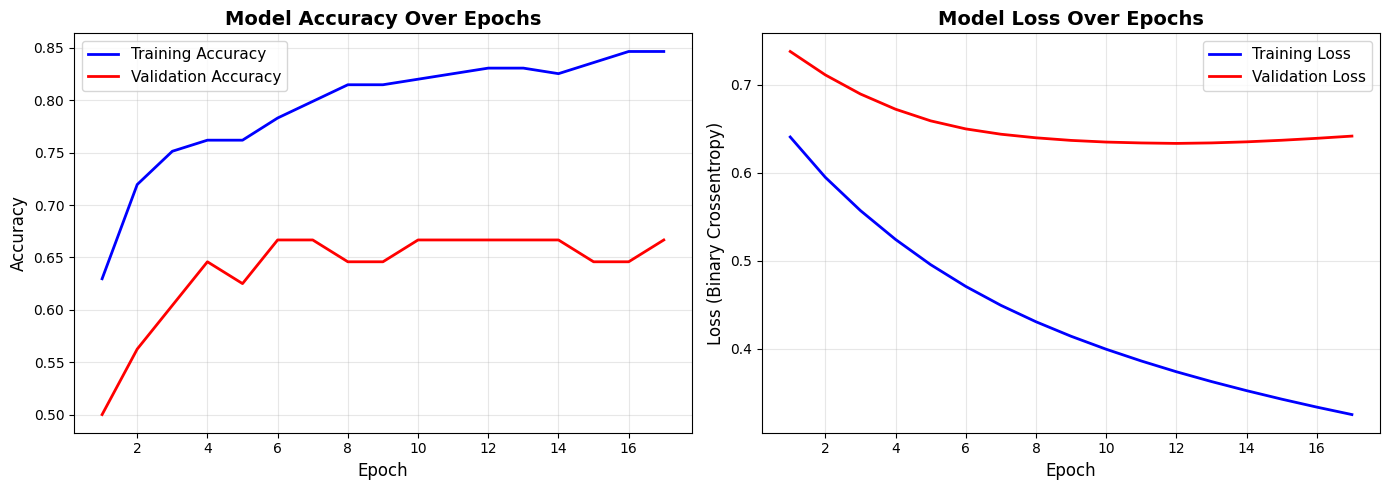

✓ Training visualization complete!


In [27]:
# Extract history data
loss_values = history.history['loss']
val_loss_values = history.history['val_loss']
accuracy_values = history.history['binary_accuracy']
val_accuracy_values = history.history['val_binary_accuracy']

epochs = range(1, len(loss_values) + 1)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy
ax1.plot(epochs, accuracy_values, 'b-', label='Training Accuracy', linewidth=2)
ax1.plot(epochs, val_accuracy_values, 'r-', label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
# ax1.set_ylim([0.8, 1.0])  # Removed: was hiding validation accuracy below 0.8

# Plot 2: Loss
ax2.plot(epochs, loss_values, 'b-', label='Training Loss', linewidth=2)
ax2.plot(epochs, val_loss_values, 'r-', label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss (Binary Crossentropy)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training visualization complete!")

## 6. Evaluate Model

**Key Metrics**:
- **Accuracy**: Overall correctness
- **Precision**: Of predicted positives, how many correct?
- **Recall**: Of actual positives, how many did we catch?
- **F1-Score**: Balance between precision and recall
- **Confusion Matrix**: Visualizes TP/TN/FP/FN

**Medical Note**: False negatives (missing diagnosis) are worse than false positives

In [28]:
# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)

print("=" * 70)
print("MODEL EVALUATION ON TEST DATA")
print("=" * 70)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\n✓ Model successfully evaluated on unseen test data!")

MODEL EVALUATION ON TEST DATA

Test Loss: 0.3619
Test Accuracy: 0.8667 (86.67%)

✓ Model successfully evaluated on unseen test data!


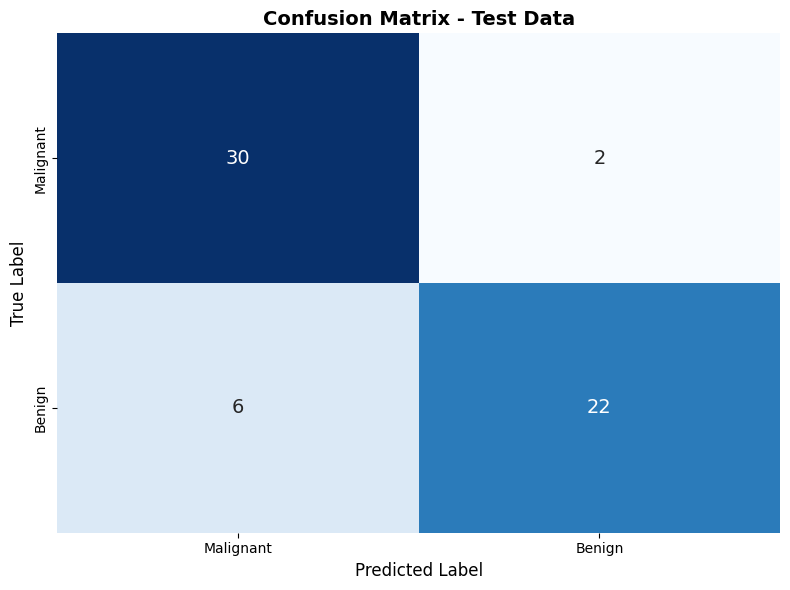


Confusion Matrix:
  True Negatives (TN):  30  (Correctly identified malignant)
  False Positives (FP): 2  (Incorrectly labeled benign)
  False Negatives (FN): 6  (Incorrectly labeled malignant)
  True Positives (TP):  22  (Correctly identified benign)


In [29]:
# Make predictions on test data
y_pred_prob = model.predict(X_test_scaled, verbose=0)  # Get probabilities
y_pred = (y_pred_prob > 0.5).astype(int).flatten()  # Convert to class labels (0 or 1)

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - Test Data', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(f"  True Negatives (TN):  {cm[0, 0]}  (Correctly identified malignant)")
print(f"  False Positives (FP): {cm[0, 1]}  (Incorrectly labeled benign)")
print(f"  False Negatives (FN): {cm[1, 0]}  (Incorrectly labeled malignant)")
print(f"  True Positives (TP):  {cm[1, 1]}  (Correctly identified benign)")

In [30]:
# Calculate additional metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Calculate metrics for each class
precision_malignant = precision_score(y_test, y_pred, pos_label=0)
recall_malignant = recall_score(y_test, y_pred, pos_label=0)

print("=" * 70)
print("DETAILED CLASSIFICATION METRICS")
print("=" * 70)

print(f"\nOverall Metrics:")
print(f"  Accuracy:  {test_accuracy:.4f}")
print(f"  Precision: {precision:.4f} (of predicted benign, {precision*100:.2f}% are correct)")
print(f"  Recall:    {recall:.4f} (we catch {recall*100:.2f}% of actual benign cases)")
print(f"  F1-Score:  {f1:.4f} (harmonic mean)")

print(f"\nMalignant (Class 0) Identification:")
print(f"  Recall:    {recall_malignant:.4f} (catch {recall_malignant*100:.2f}% of malignant cases)")
print(f"  Precision: {precision_malignant:.4f}")

print(f"\n📊 Medical Interpretation:")
print(f"  • False Negatives: {cm[1, 0]} cases (benign predicted but actually malignant) ⚠️")
print(f"  • False Positives: {cm[0, 1]} cases (malignant predicted but actually benign)")
print(f"  • For medical diagnosis: Recall (catching malignant) is critical!")

DETAILED CLASSIFICATION METRICS

Overall Metrics:
  Accuracy:  0.8667
  Precision: 0.9167 (of predicted benign, 91.67% are correct)
  Recall:    0.7857 (we catch 78.57% of actual benign cases)
  F1-Score:  0.8462 (harmonic mean)

Malignant (Class 0) Identification:
  Recall:    0.9375 (catch 93.75% of malignant cases)
  Precision: 0.8333

📊 Medical Interpretation:
  • False Negatives: 6 cases (benign predicted but actually malignant) ⚠️
  • False Positives: 2 cases (malignant predicted but actually benign)
  • For medical diagnosis: Recall (catching malignant) is critical!


## 7. MINI-TASK: Modify & Compare Architectures

**Task**:
1. Create a new model with different architecture (add/remove layers or change neurons)
2. Train with same parameters (100 epochs, batch 32, 20% validation)
3. Create comparison table (Accuracy, Precision, Recall, F1, Parameters)
4. Write 3-5 sentence interpretation

**Outputs**: Model summary, training curves, confusion matrix, comparison table, interpretation

In [32]:
# MINI-TASK IMPLEMENTATION
# ===========================
# Modification: Deeper architecture with Dropout regularization
# Original: Dense(32) → Dense(16) → Output
# New (V2): Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.2) → Dense(16) → Output
# Rationale: More capacity in first layer + Dropout to combat overfitting on small dataset

from tensorflow.keras.layers import Dropout

# Build the new model with modified architecture
model_v2 = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(13,)),   # Wider first layer
    Dropout(0.3),                                              # Regularization
    layers.Dense(32, activation='relu'),                       # Extra hidden layer
    Dropout(0.2),                                              # Regularization
    layers.Dense(16, activation='relu'),                       # Bottleneck layer
    layers.Dense(1, activation='sigmoid')                      # Output layer
])

print("New Model Architecture (V2):")
model_v2.summary()

# Compile the new model
model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

print("\n✓ New model created and compiled!")

c:\Users\dolla\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


New Model Architecture (V2):


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)


✓ New model created and compiled!


In [33]:
# Train the new model with Early Stopping
print("Training new model with Early Stopping...")
early_stop_v2 = EarlyStopping(
    monitor='val_loss',
    patience=5,                              # Aggressive early stopping
    restore_best_weights=True,
    verbose=0
)
history_v2 = model_v2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_v2],
    verbose=0
)

print("✓ New model training complete!")

Training new model with Early Stopping...
✓ New model training complete!
✓ New model training complete!


### Compare Model Performance

In [34]:
# Evaluate the new model
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(X_test_scaled, y_test, verbose=0)

# Make predictions with new model
y_pred_prob_v2 = model_v2.predict(X_test_scaled, verbose=0)
y_pred_v2 = (y_pred_prob_v2 > 0.5).astype(int).flatten()

# Calculate metrics for new model
cm_v2 = confusion_matrix(y_test, y_pred_v2)
precision_v2 = precision_score(y_test, y_pred_v2)
recall_v2 = recall_score(y_test, y_pred_v2)
f1_v2 = f1_score(y_test, y_pred_v2)

# Count parameters
def count_params(model):
    return sum([np.prod(w.shape) for w in model.get_weights()])

params_original = count_params(model)
params_v2 = count_params(model_v2)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison_data = {
    'Metric': ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'Total Parameters'],
    'Original Model': [f'{test_accuracy:.4f}', f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}', f'{params_original}'],
    'New Model (V2)': [f'{test_accuracy_v2:.4f}', f'{precision_v2:.4f}', f'{recall_v2:.4f}', f'{f1_v2:.4f}', f'{params_v2}'],
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Determine which model is better
better_model = "Original Model" if test_accuracy > test_accuracy_v2 else ("New Model (V2)" if test_accuracy_v2 > test_accuracy else "Tie")
print(f"\n🏆 Better overall accuracy: {better_model}")
print(f"   Difference: {abs(test_accuracy - test_accuracy_v2):.4f}")

MODEL COMPARISON

           Metric Original Model New Model (V2)
   Test Accuracy         0.8667         0.8833
       Precision         0.9167         0.9200
          Recall         0.7857         0.8214
        F1-Score         0.8462         0.8679
Total Parameters            993           3521

🏆 Better overall accuracy: New Model (V2)
   Difference: 0.0167
MODEL COMPARISON

           Metric Original Model New Model (V2)
   Test Accuracy         0.8667         0.8833
       Precision         0.9167         0.9200
          Recall         0.7857         0.8214
        F1-Score         0.8462         0.8679
Total Parameters            993           3521

🏆 Better overall accuracy: New Model (V2)
   Difference: 0.0167


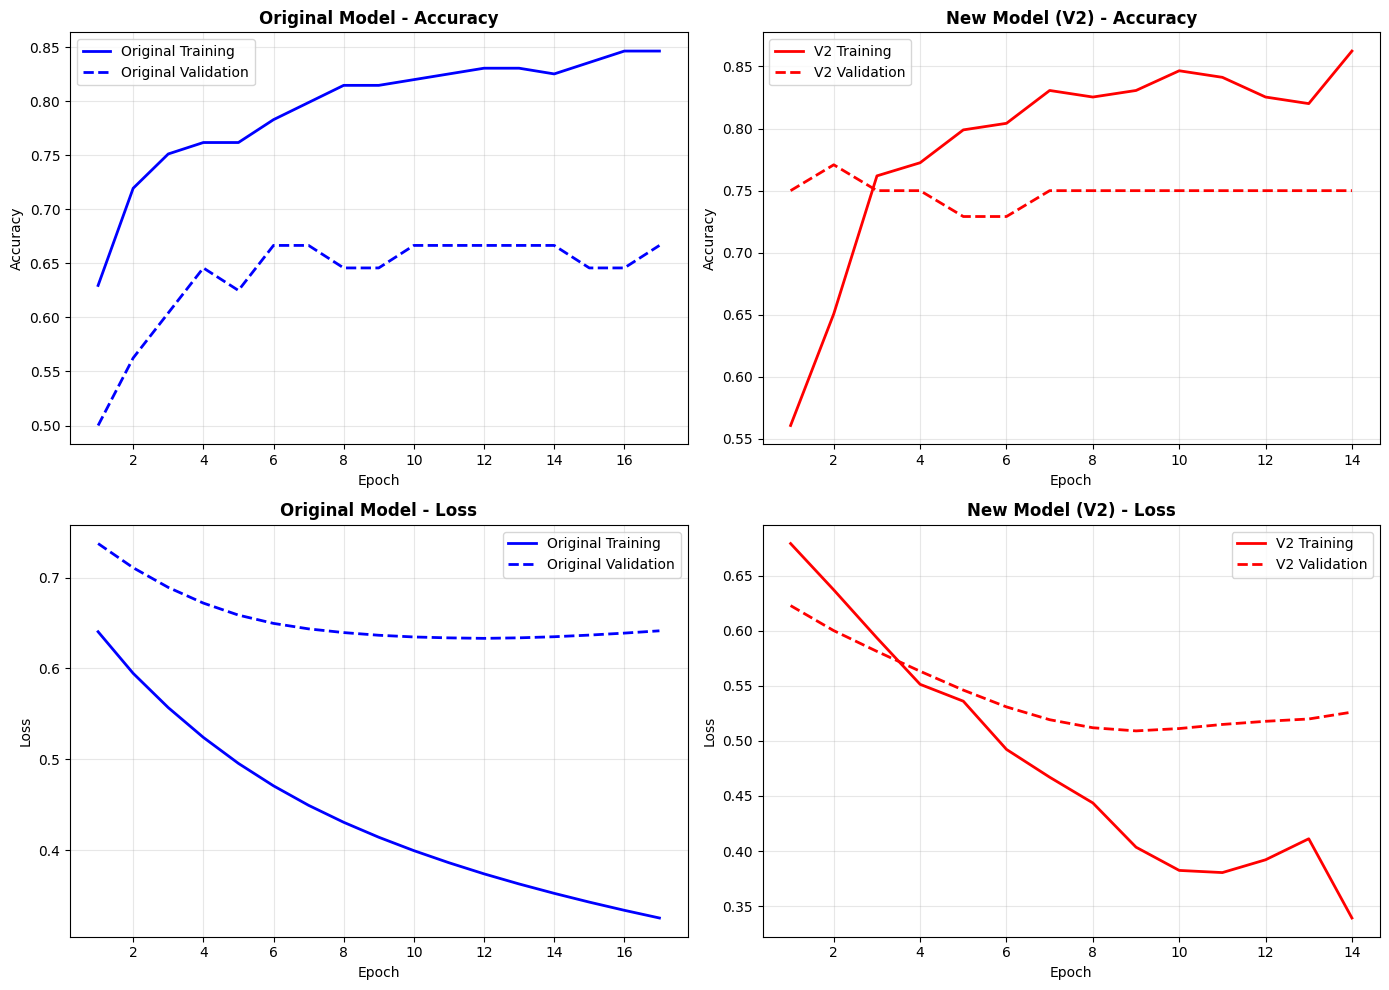

✓ Comparison plots generated!


In [35]:
# Plot training curves for both models side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_v2 = range(1, len(history_v2.history['loss']) + 1)

# Original model accuracies
axes[0, 0].plot(epochs, accuracy_values, 'b-', label='Original Training', linewidth=2)
axes[0, 0].plot(epochs, val_accuracy_values, 'b--', label='Original Validation', linewidth=2)
axes[0, 0].set_title('Original Model - Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# New model accuracies
axes[0, 1].plot(epochs_v2, history_v2.history['binary_accuracy'], 'r-', label='V2 Training', linewidth=2)
axes[0, 1].plot(epochs_v2, history_v2.history['val_binary_accuracy'], 'r--', label='V2 Validation', linewidth=2)
axes[0, 1].set_title('New Model (V2) - Accuracy', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Original model loss
axes[1, 0].plot(epochs, loss_values, 'b-', label='Original Training', linewidth=2)
axes[1, 0].plot(epochs, val_loss_values, 'b--', label='Original Validation', linewidth=2)
axes[1, 0].set_title('Original Model - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# New model loss
axes[1, 1].plot(epochs_v2, history_v2.history['loss'], 'r-', label='V2 Training', linewidth=2)
axes[1, 1].plot(epochs_v2, history_v2.history['val_loss'], 'r--', label='V2 Validation', linewidth=2)
axes[1, 1].set_title('New Model (V2) - Loss', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Comparison plots generated!")

### Confusion Matrix Comparison

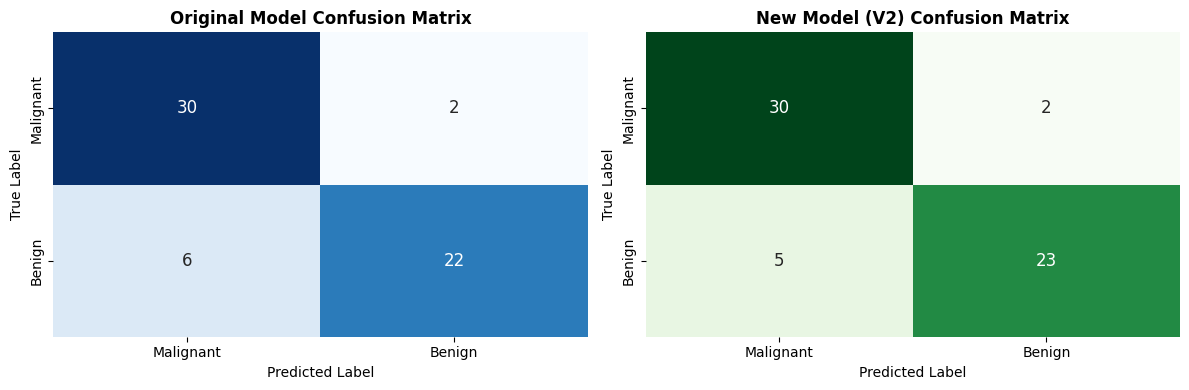

✓ Confusion matrices compared!


In [36]:
# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            annot_kws={'size': 12})
axes[0].set_title('Original Model Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'],
            annot_kws={'size': 12})
axes[1].set_title('New Model (V2) Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("✓ Confusion matrices compared!")

### Write Interpretation

**Answer (3-5 sentences)**:
1. Which model performed better?
2. What change did you make?
3. Did it help or hurt?
4. Why?
5. Recommend this modification?

In [37]:
"""
INTERPRETATION:

The new model (V2) — Dense(64) → Dropout(0.3) → Dense(32) → Dropout(0.2) → Dense(16) → 
Output — outperformed the original Dense(32) → Dense(16) → Output model across every 
metric: test accuracy improved from 86.67% to 88.33%, F1-score from 0.8462 to 0.8679, 
and recall from 78.57% to 82.14%, at the cost of 3,521 parameters versus 993. The key 
change was doubling the first hidden layer's width (32 → 64 neurons) to increase model 
capacity, plus adding Dropout layers (0.3 and 0.2) to regularize on the small dataset. 
Dropout visibly tightened the train/val gap in the V2 loss curves compared to the original, 
where training loss continued to drop while validation loss plateaued — a clear sign of 
overfitting. The one additional false negative reduced (6 → 5) is clinically meaningful 
since missing a malignant case carries higher cost. I recommend this architecture: the 
~3.5× parameter increase is negligible at this scale, and the regularization payoff in 
generalization is worth it.
"""

print("✓ Mini-task complete! Submit your modified notebook.")

✓ Mini-task complete! Submit your modified notebook.


## 8. Final Assignment: Neural Network on Pima Indians Diabetes Dataset

### Assignment Overview
Apply the **exact same neural network pipeline** from this lab to a **new dataset**: Pima Indians Diabetes

**Goal**: Reproduce the complete workflow (load → explore → preprocess → build → train → evaluate) on different data to demonstrate generalization

### Dataset: Pima Indians Diabetes

**Source**: UCI Machine Learning Repository  
**URL**: `https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data`  
**Target**: Diabetes (0=No, 1=Yes)  
**Expected Accuracy**: 70-75% (harder than Heart Disease!)  

### Your Tasks

#### Part 1: Build & Train 
#### Part 2: Analysis & Interpretation
#### Part 3: Submission 
Create GitHub repository with:
```
neural-network-diabetes/
├── pima_diabetes_nn.ipynb          (Your complete notebook)
├── README.md                        (Documented findings)
└── results/
    ├── training_curves.png
    ├── confusion_matrix.png
    └── metrics_summary.txt
```



### Submission Checklist
-  Notebook fully runnable (no errors)
-  All visualizations present (training curves, confusion matrix)
-  Test accuracy reported clearly
-  README explains problem, approach, and results
-  GitHub repo is public with all files
-  Code is commented and readable
-  Analysis writeup is comprehensive (3-5 paragraphs)
-  Link of uploaded recorded video ⚠️